Original Dataset
  User_ID  Basket_Size  Total_Spent
0      U1           12          140
1      U2            2           15
2      U3           15          180
3      U4            3           22
4      U5            8           95

Normalized Data
[[0.76923077 0.75757576]
 [0.         0.        ]
 [1.         1.        ]
 [0.07692308 0.04242424]
 [0.46153846 0.48484848]]

Cluster Assignment
  User_ID  Basket_Size  Total_Spent  Cluster
0      U1           12          140        2
1      U2            2           15        1
2      U3           15          180        2
3      U4            3           22        1
4      U5            8           95        3


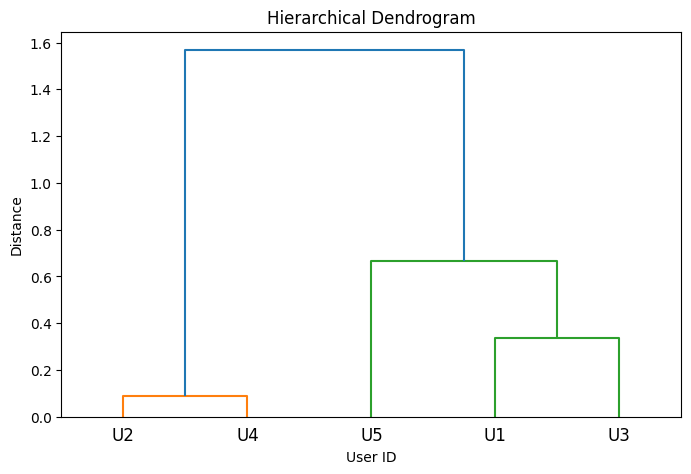


Cluster Interpretation

Cluster 1
  User_ID  Basket_Size  Total_Spent
1      U2            2           15
3      U4            3           22

Cluster 2
  User_ID  Basket_Size  Total_Spent
0      U1           12          140
2      U3           15          180

Cluster 3
  User_ID  Basket_Size  Total_Spent
4      U5            8           95


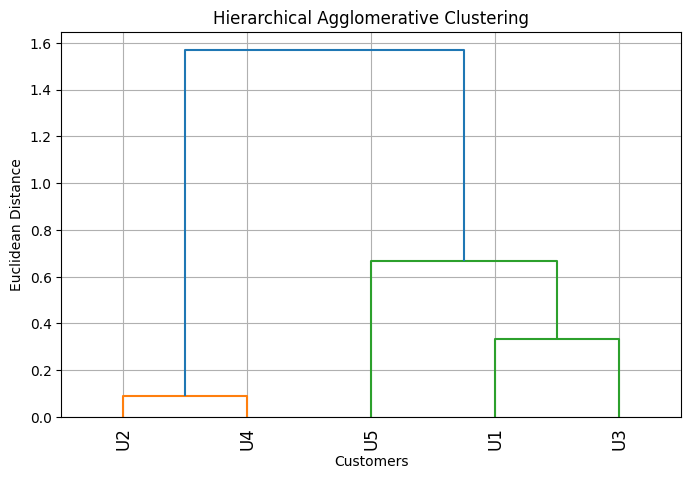

In [2]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Step 1: Create Dataset
data = {
    'User_ID': ['U1', 'U2', 'U3', 'U4', 'U5'],
    'Basket_Size': [12, 2, 15, 3, 8],
    'Total_Spent': [140, 15, 180, 22, 95]
}

df = pd.DataFrame(data)

print("Original Dataset")
print(df)

# -----------------------------
# Question 1
# Min-Max Normalization
# -----------------------------

X = df[['Basket_Size', 'Total_Spent']]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("\nNormalized Data")
print(X_scaled)

# -----------------------------
# Question 2
# Hierarchical Clustering
# -----------------------------

Z = linkage(X_scaled, method='ward')

clusters = fcluster(Z, t=0.5, criterion='distance')

df['Cluster'] = clusters

print("\nCluster Assignment")
print(df)

# -----------------------------
# Question 3
# Dendrogram
# -----------------------------

plt.figure(figsize=(8,5))

dendrogram(
    Z,
    labels=df['User_ID'].values
)

plt.title("Hierarchical Dendrogram")
plt.xlabel("User ID")
plt.ylabel("Distance")

plt.show()

# -----------------------------
# Question 4
# Cluster Interpretation
# -----------------------------

print("\nCluster Interpretation")

for i in sorted(df['Cluster'].unique()):
    print(f"\nCluster {i}")
    print(df[df['Cluster']==i][['User_ID','Basket_Size','Total_Spent']])

# -----------------------------
# Question 5
# Dendrogram Diagram
# -----------------------------

plt.figure(figsize=(8,5))

dendrogram(
    Z,
    labels=df['User_ID'].values,
    leaf_rotation=90,
    leaf_font_size=12
)

plt.title("Hierarchical Agglomerative Clustering")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.grid()

plt.show()